In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("titanic_data.csv")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
#Veri tipleri kontrol
df.info()
df.dtypes
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     889 non-null    int64  
 1   pclass       889 non-null    int64  
 2   sex          889 non-null    object 
 3   age          713 non-null    float64
 4   sibsp        889 non-null    int64  
 5   parch        889 non-null    int64  
 6   fare         889 non-null    float64
 7   embarked     887 non-null    object 
 8   class        889 non-null    object 
 9   who          889 non-null    object 
 10  adult_male   889 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  887 non-null    object 
 13  alive        889 non-null    object 
 14  alone        889 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.2+ KB


,survived,pclass,age,sibsp,parch,fare
count,889.000000,889.000000,713.000000,889.000000,889.000000,889.000000
mean,0.384702,2.307087,29.698696,0.523060,0.382452,32.259059
std,0.486799,0.836367,14.536691,1.103729,0.806761,49.735870
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.000000,0.000000,0.000000,7.925000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            176
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           686
embark_town      2
alive            0
alone            0
dtype: int64

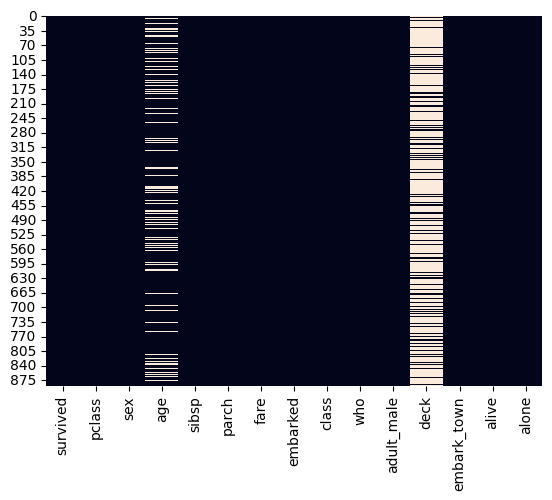

In [4]:
#Görsel kontrol
sns.heatmap(df.isnull(), cbar=False)
plt.show()

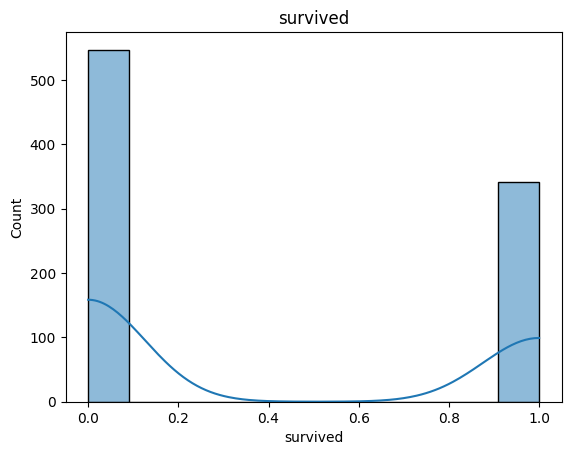

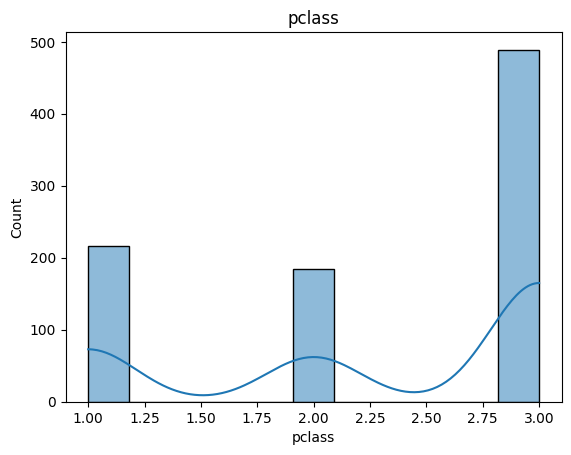

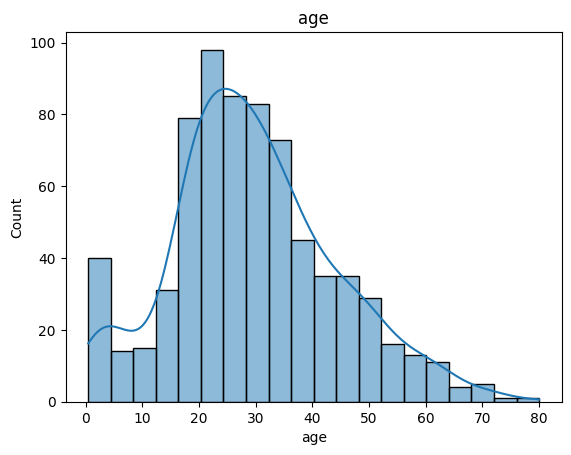

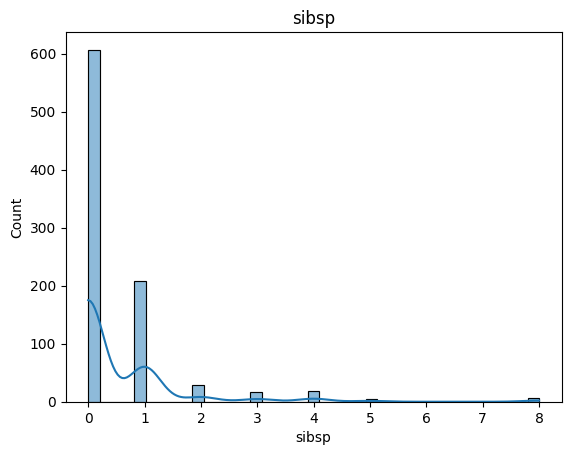

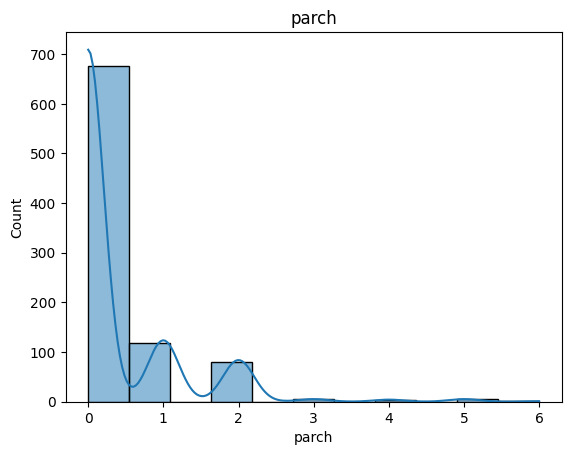

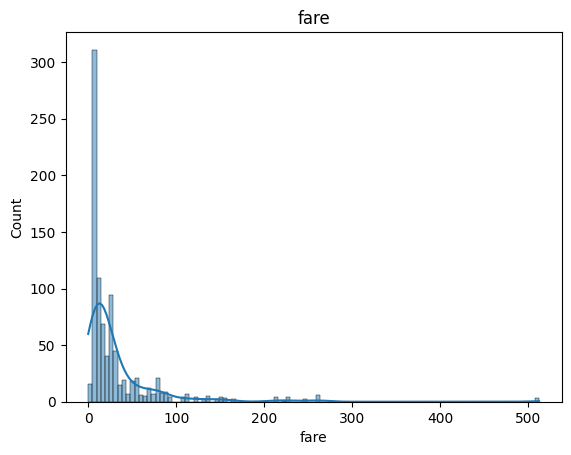

In [5]:
#Gürültü kontrol
for col in df.select_dtypes(include=np.number).columns:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

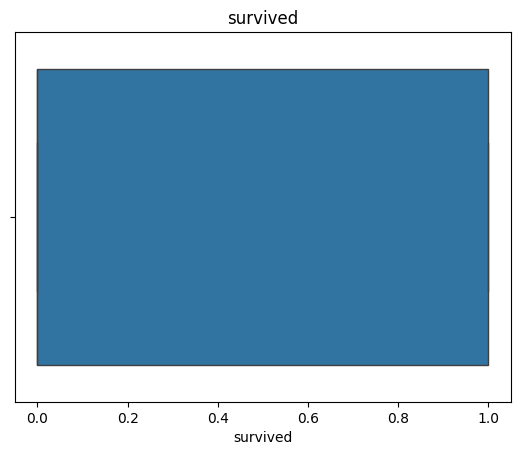

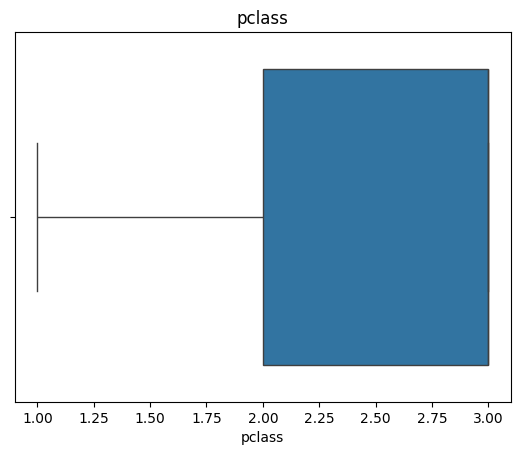

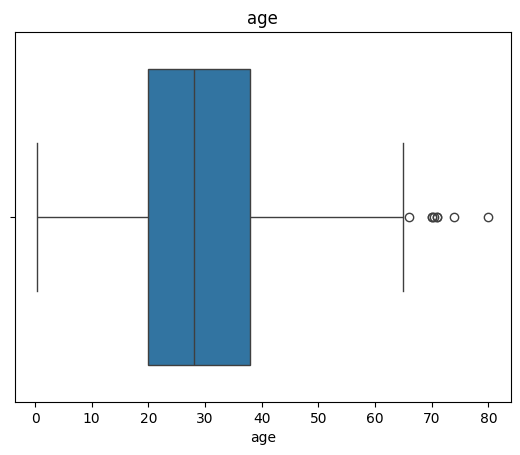

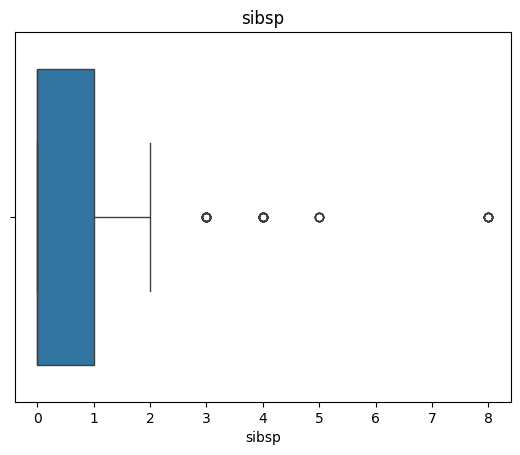

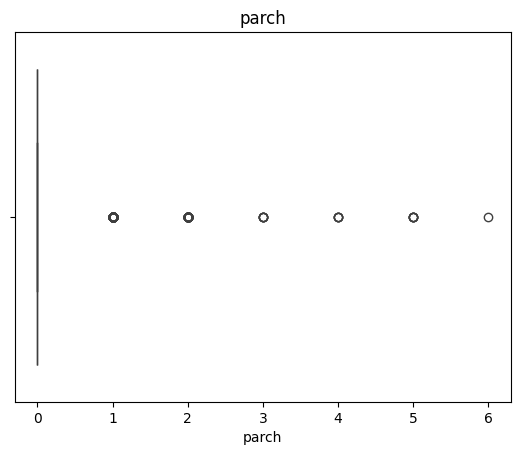

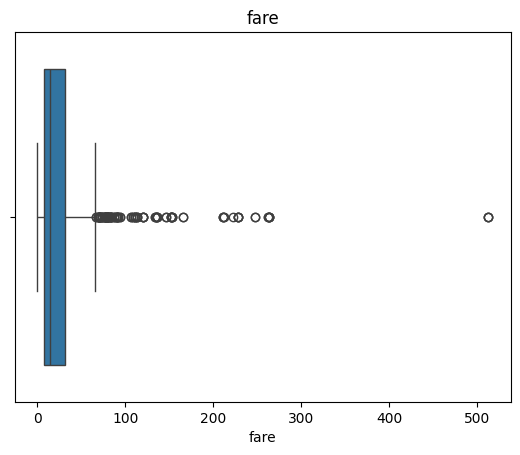

In [6]:
#Aykırı değer boxplot
for col in df.select_dtypes(include=np.number).columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [7]:
#Aykırı değer IQR
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[col] < lower) | (df[col] > upper)]

detect_outliers(df, "fare")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False
31,1,1,female,NaN,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,NaN,Cherbourg,no,False
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
844,0,3,male,NaN,8,2,69.5500,S,Third,man,True,NaN,Southampton,no,False
847,1,1,female,NaN,1,0,89.1042,C,First,woman,False,C,Cherbourg,yes,False
854,1,1,female,45.0,1,1,164.8667,S,First,woman,False,NaN,Southampton,yes,False
861,0,3,female,NaN,8,2,69.5500,S,Third,woman,False,NaN,Southampton,no,False


In [8]:
#Veri Temizleme
df_clean = df.copy()
drop_cols = ["name","ticket","cabin","passengerid","alive"]
drop_cols = [c for c in drop_cols if c in df_clean.columns]
df_clean = df_clean.drop(columns=drop_cols)

In [13]:
#Eksik veri doldurma
if "age" in df_clean.columns:
    df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

if "deck" in df_clean.columns:
    df_clean["deck"] = df_clean["deck"].fillna(df_clean["deck"].mode()[0])

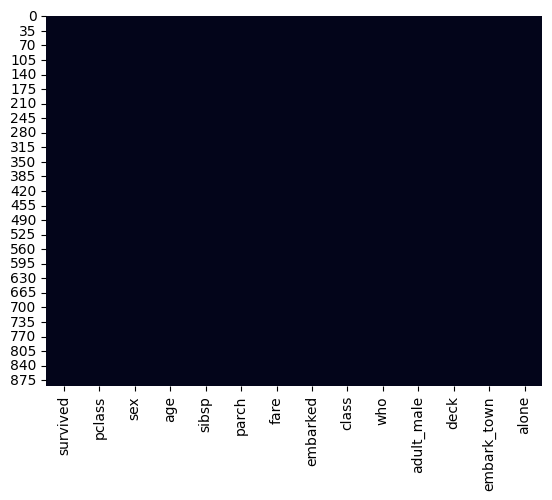

In [14]:
#Görsel kontrol
sns.heatmap(df_clean.isnull(), cbar=False)
plt.show()

In [19]:
#Aykırı değer capping
if "age" in df_clean.columns:
    Q1 = df_clean["age"].quantile(0.25)
    Q3 = df_clean["age"].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_clean["age"] = np.clip(df_clean["age"], lower, upper)

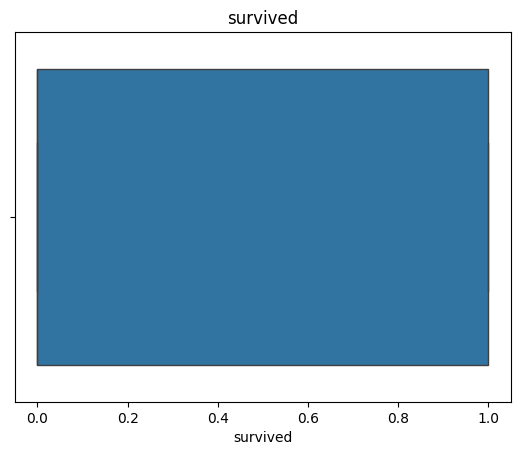

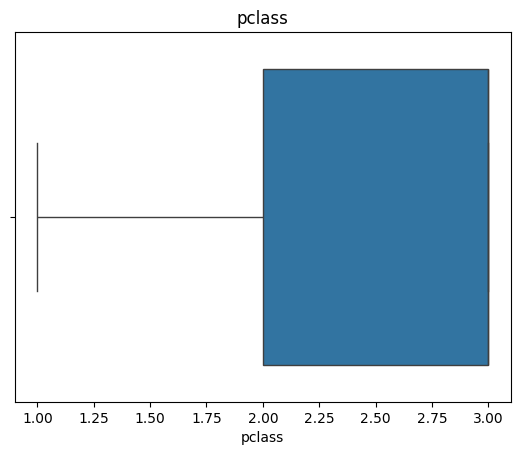

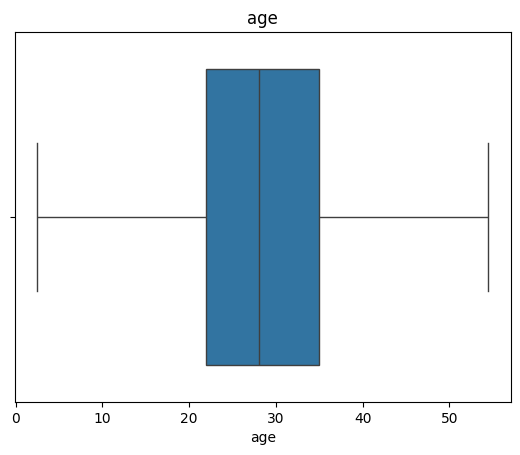

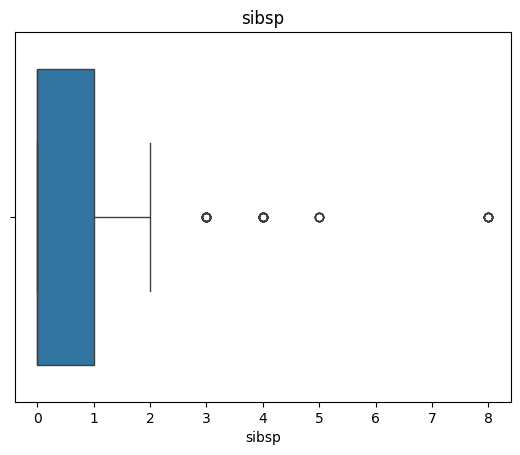

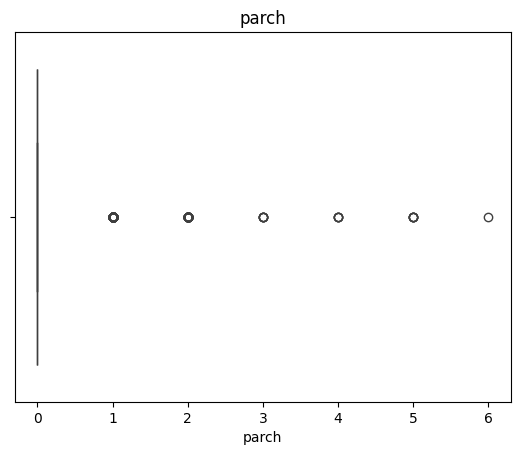

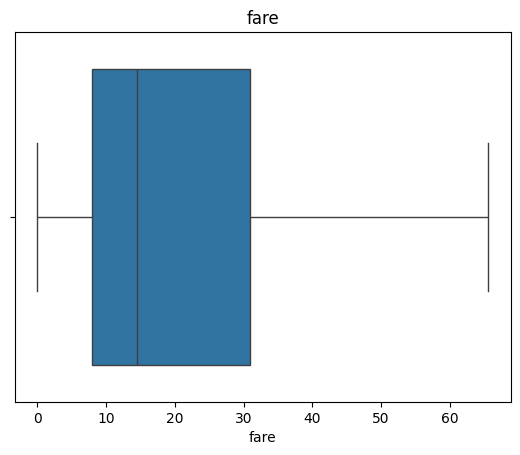

In [20]:
#Aykırı değer boxplot
for col in df_clean.select_dtypes(include=np.number).columns:
    plt.figure()
    sns.boxplot(x=df_clean[col])
    plt.title(col)
    plt.show()